In [3]:
!hostname

aga37


In [1]:
import pandas as pd
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
base_dir = '/users/6/mehta423/projects/daycent/data/SAS_KGML_090925'
input_dir = os.path.join(base_dir, 'InputData')
output_dir_synthetic = os.path.join(base_dir, 'OutputData_Synthetic_10000')
POINTS_LOOKUP = os.path.join(base_dir, "SAS_points_lookup.csv")


# EDA for Inputs

In [ ]:
synthetic_schedule_df = pd.read_csv(os.path.join(input_dir, 'schedule_scenarios_all_Synthetic_10000.csv'))
realistic_schedule_df = pd.read_csv(os.path.join(input_dir, 'schedule_scenarios_all_Realistic_8.csv'))
print(synthetic_schedule_df.head())
print(synthetic_schedule_df['scenario'].unique())
print(synthetic_schedule_df['doy'].unique())
print(synthetic_schedule_df['management'].unique())
print(synthetic_schedule_df['management'].nunique())

# find all unique management events in all the files in the realistic and synthetic dfs
management_events = set()

df = pd.concat([synthetic_schedule_df, realistic_schedule_df])
for mgmt in df['management'].unique():
    management_events.add(mgmt)

print(len(management_events))

     scenario  simyear  doy                      management
0  scenario_1     2000  132   conventional_till_molboadplow
1  scenario_1     2000  136                       herbicide
2  scenario_1     2000  137                soybean_planting
3  scenario_1     2000  137  nitrogen_fertilization_1.5gNm2
4  scenario_1     2000  289                   harvest_grain
['scenario_1' 'scenario_2' 'scenario_3' ... 'scenario_9998'
 'scenario_9999' 'scenario_10000']
[132 136 137 289 294 311 127 130 310 125 129 305 299 184 185 120 315 200
 205 189 201 290 128 131]
['conventional_till_molboadplow' 'herbicide' 'soybean_planting'
 'nitrogen_fertilization_1.5gNm2' 'harvest_grain' 'cycle_end'
 'ryegrass_planting' 'nitrogen_fertilization_0gNm2'
 'reduced_till_tandemdisk' 'notill_rodweederrow' 'corn_planting'
 'nitrogen_fertilization_17.74gNm2' 'winterwheat_planting'
 'nitrogen_fertilization_10.312gNm2']
14
14


In [56]:
print(df['management'].value_counts())

# year wise distribution of management events of all scenarios. year is given in simyear column
df.groupby(['simyear', 'management']).size().unstack(fill_value=0)


management
cycle_end                            268494
harvest_grain                        215332
herbicide                            143495
notill_rodweederrow                  129109
conventional_till_molboadplow        129050
reduced_till_tandemdisk              128144
soybean_planting                      75263
nitrogen_fertilization_1.5gNm2        75263
winterwheat_planting                  71556
nitrogen_fertilization_10.312gNm2     71556
nitrogen_fertilization_17.74gNm2      70921
corn_planting                         70921
ryegrass_planting                     54986
nitrogen_fertilization_0gNm2          16425
Name: count, dtype: int64


management,conventional_till_molboadplow,corn_planting,cycle_end,harvest_grain,herbicide,nitrogen_fertilization_0gNm2,nitrogen_fertilization_1.5gNm2,nitrogen_fertilization_10.312gNm2,nitrogen_fertilization_17.74gNm2,notill_rodweederrow,reduced_till_tandemdisk,ryegrass_planting,soybean_planting,winterwheat_planting
simyear,,,,,,,,,,,,,,
2000,5903,3990,8005,8005,8005,648,4015,5339,3990,6175,5935,2061,4015,5339
2001,4603,1967,11421,9360,4022,648,2054,676,1967,4785,4635,4720,2054,676
2002,5903,3955,13401,8681,8007,648,4050,5339,3955,6175,5935,2062,4050,5339
2003,4559,1578,11287,9225,3348,648,2308,1410,1578,4712,4617,142,2308,1410
2004,5951,3831,9291,9149,7740,691,3908,4470,3831,5965,5828,2734,3908,4470
2005,4789,2183,11511,8777,4309,691,2124,1500,2183,4785,4738,4012,2124,1500
2006,5955,3788,13245,9233,7698,691,3945,4117,3788,5958,5825,1933,3945,4117
2007,5100,2192,10991,9058,4417,799,2749,1923,2192,4931,4915,598,2749,1923
2008,5752,3543,9679,9081,7161,658,3615,3935,3543,5576,5835,2970,3615,3935


In [62]:
weather_df = pd.read_csv('/users/6/mehta423/projects/daycent/data/SAS_KGML_090925/InputData/WeatherData/657200.csv')
# find month given day of year
weather_df['month'] = pd.to_datetime(weather_df['doy'], format='%j').dt.month



monthly_weather = weather_df.groupby(['Year','month']).agg({'Tmin':'mean','Tmax':'mean','Precip':'sum'})
print(monthly_weather.describe())

weather_df.isna().sum()

             Tmin        Tmax      Precip
count  300.000000  300.000000  300.000000
mean     5.489942   15.741818    8.822742
std      9.226116   10.443813    5.049413
min    -14.367143   -4.354286    1.608000
25%     -2.629742    5.717419    5.256500
50%      5.451468   16.672489    7.642000
75%     14.866411   26.046500   11.236500
max     19.989677   32.242581   37.756400


Year      0
doy       0
Tmax      0
Tmin      0
Precip    0
month     0
dtype: int64

In [75]:
inital_conditions_df = pd.read_excel('/users/6/mehta423/projects/daycent/data/SAS_KGML_090925/InputData/initial_site_conditions.xlsx')
print(inital_conditions_df.head())
summary = inital_conditions_df.describe().T[['mean','std','min','max']]
print(summary.sort_values(by='std', ascending=False).head(21))

        id  PRECIP(1)  PRECIP(2)  PRECIP(3)  PRECIP(4)  PRECIP(5)  PRECIP(6)  \
0  1773513        5.2        4.6        6.0        9.1       10.2        9.4   
1  1773576        5.4        5.1        6.3        8.9       10.5        9.4   
2  1773749        5.3        4.7        6.2        8.9       10.9        9.6   
3  1773883        5.2        4.8        6.2        8.7       10.6        9.5   
4  1774020        5.2        4.9        6.1        8.7        9.8        9.2   

   PRECIP(7)  PRECIP(8)  PRECIP(9)  ...  SWCINI(6)  SWCINI(7)  SWCINI(8)  \
0        8.8        8.1        8.2  ...    3.61072    3.53220    2.72488   
1        9.7        8.1        7.9  ...    3.42585    3.45882    3.45701   
2        9.0        8.3        8.3  ...    6.62720    6.62729    6.95545   
3        9.2        7.9        8.0  ...    6.62717    6.62729    6.95545   
4        9.3        8.6        8.1  ...    5.89078    5.89080    5.89079   

   SWCINI(9)  SWCINI(10)  SWCINI(11)  SWCINI(12)  SWCINI(13)  

In [14]:
number_of_points = len(os.listdir(input_dir + '/WeatherData'))
print(f'Number of weather points: {number_of_points}')

Number of weather points: 203


In [47]:
harvest_df = pd.read_csv('/users/6/mehta423/projects/daycent/data/SAS_KGML_090925/OutputData_Realistic_8/SAS_current_4_CS_R3_RT__monthly.csv')
print(harvest_df.head())

   runid      id  simyear  month    somsc
0      1  657200  2001.00      1  5086.97
1      1  657200  2001.08      2  5088.75
2      1  657200  2001.17      3  5090.38
3      1  657200  2001.25      4  5092.12
4      1  657200  2001.33      5  5094.77


In [48]:
print(harvest_df['id'].value_counts())

id
657200     289
657271     289
657277     289
657532     289
657791     289
          ... 
1798503    289
1798799    289
1798896    289
1799548    289
1799675    289
Name: count, Length: 203, dtype: int64


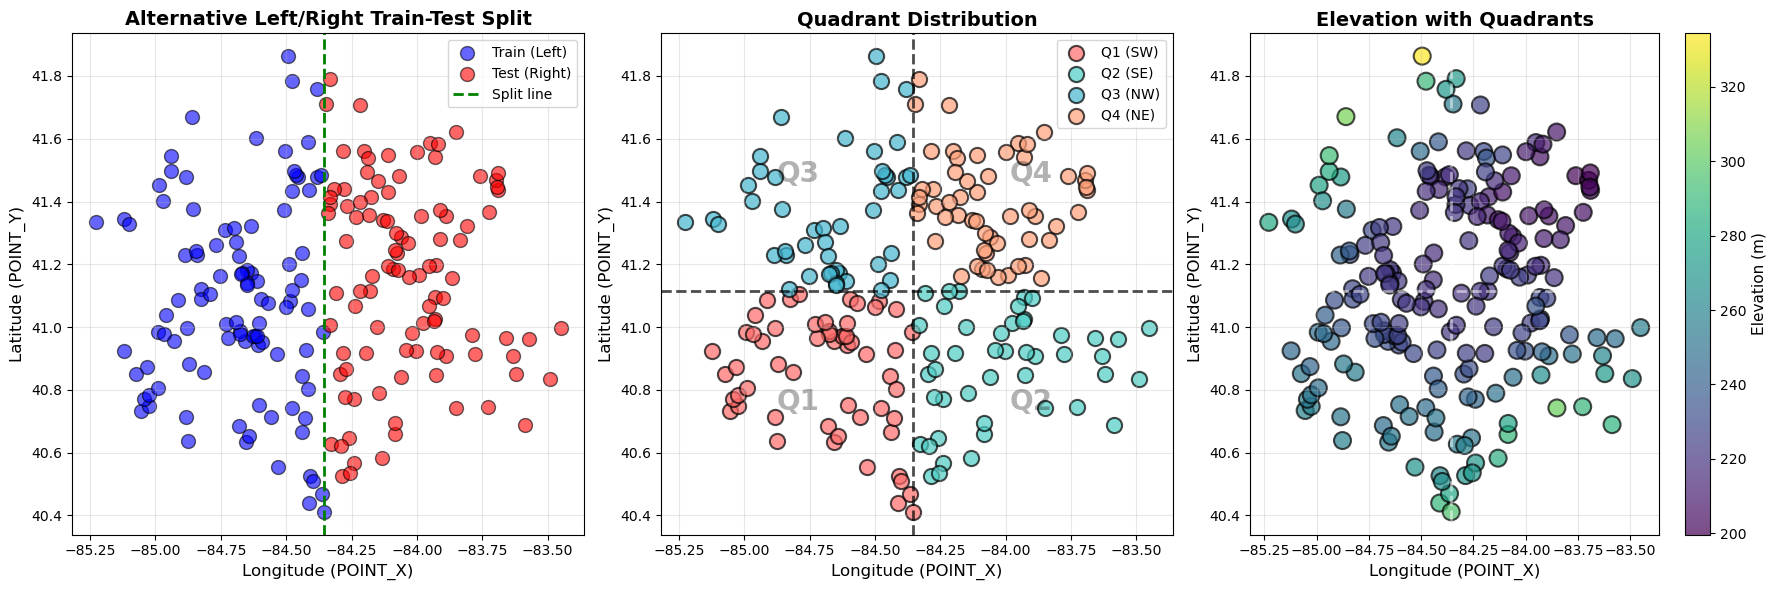

SPATIAL SPLIT SUMMARY

Total points: 203
Split boundary X (Longitude): -84.356291
Split boundary Y (Latitude): 41.114184

--- LEFT/RIGHT SPLIT ---
Training points (Left): 102 (50.2%)
Testing points (Right): 101 (49.8%)

--- QUADRANT DISTRIBUTION ---
Q1 (SW): 56 points (27.6%)
Q2 (SE): 46 points (22.7%)
Q3 (NW): 46 points (22.7%)
Q4 (NE): 55 points (27.1%)

--- ELEVATION STATISTICS BY QUADRANT ---
Q1 (SW): Mean=243.08m, Min=218.91m, Max=296.27m
Q2 (SE): Mean=247.91m, Min=219.07m, Max=303.72m
Q3 (NW): Mean=241.20m, Min=215.65m, Max=334.37m
Q4 (NE): Mean=216.81m, Min=199.67m, Max=272.41m

ALTERNATIVE: CHECKERBOARD TRAIN-TEST SPLIT
Train (Q1): 56 points
Test (Q4): 55 points


In [6]:
df = pd.read_csv(POINTS_LOOKUP)

# Calculate medians for splitting
median_x = df['POINT_X'].median()
median_y = df['POINT_Y'].median()

# Create quadrants
df['quadrant'] = 'Q1'
df.loc[(df['POINT_X'] <= median_x) & (df['POINT_Y'] <= median_y), 'quadrant'] = 'Q1 (SW)'
df.loc[(df['POINT_X'] > median_x) & (df['POINT_Y'] <= median_y), 'quadrant'] = 'Q2 (SE)'
df.loc[(df['POINT_X'] <= median_x) & (df['POINT_Y'] > median_y), 'quadrant'] = 'Q3 (NW)'
df.loc[(df['POINT_X'] > median_x) & (df['POINT_Y'] > median_y), 'quadrant'] = 'Q4 (NE)'

# Method 1: Left/Right split for train-test
left_half = df[df['POINT_X'] <= median_x]
right_half = df[df['POINT_X'] > median_x]

# Visualization
fig = plt.figure(figsize=(18, 6))

# Plot 1: Left/Right Train-Test Split
ax1 = plt.subplot(131)
ax1.scatter(left_half['POINT_X'], left_half['POINT_Y'], 
           c='blue', s=100, alpha=0.6, label='Train (Left)', edgecolors='black')
ax1.scatter(right_half['POINT_X'], right_half['POINT_Y'], 
           c='red', s=100, alpha=0.6, label='Test (Right)', edgecolors='black')
ax1.axvline(median_x, color='green', linestyle='--', linewidth=2, label='Split line')
ax1.set_xlabel('Longitude (POINT_X)', fontsize=12)
ax1.set_ylabel('Latitude (POINT_Y)', fontsize=12)
ax1.set_title('Alternative Left/Right Train-Test Split', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Quadrant Visualization
ax2 = plt.subplot(132)
colors = {'Q1 (SW)': '#FF6B6B', 'Q2 (SE)': '#4ECDC4', 'Q3 (NW)': '#45B7D1', 'Q4 (NE)': '#FFA07A'}
for quadrant, color in colors.items():
    mask = df['quadrant'] == quadrant
    ax2.scatter(df.loc[mask, 'POINT_X'], df.loc[mask, 'POINT_Y'], 
               c=color, s=120, alpha=0.7, label=quadrant, edgecolors='black', linewidth=1.5)

# Add quadrant dividing lines
ax2.axvline(median_x, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax2.axhline(median_y, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Add quadrant labels in the center of each quadrant
x_min, x_max = df['POINT_X'].min(), df['POINT_X'].max()
y_min, y_max = df['POINT_Y'].min(), df['POINT_Y'].max()
ax2.text(median_x - (median_x - x_min)/2, median_y - (median_y - y_min)/2, 
         'Q1', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')
ax2.text(median_x + (x_max - median_x)/2, median_y - (median_y - y_min)/2, 
         'Q2', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')
ax2.text(median_x - (median_x - x_min)/2, median_y + (y_max - median_y)/2, 
         'Q3', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')
ax2.text(median_x + (x_max - median_x)/2, median_y + (y_max - median_y)/2, 
         'Q4', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')

ax2.set_xlabel('Longitude (POINT_X)', fontsize=12)
ax2.set_ylabel('Latitude (POINT_Y)', fontsize=12)
ax2.set_title('Quadrant Distribution', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Plot 3: Elevation by Quadrant
ax3 = plt.subplot(133)
scatter = ax3.scatter(df['POINT_X'], df['POINT_Y'], 
                     c=df['elevation'], s=150, cmap='viridis', 
                     alpha=0.7, edgecolors='black', linewidth=1.5)
ax3.axvline(median_x, color='white', linestyle='--', linewidth=2, alpha=0.5)
ax3.axhline(median_y, color='white', linestyle='--', linewidth=2, alpha=0.5)
ax3.set_xlabel('Longitude (POINT_X)', fontsize=12)
ax3.set_ylabel('Latitude (POINT_Y)', fontsize=12)
ax3.set_title('Elevation with Quadrants', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Elevation (m)', fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('spatial_analysis_quadrants.png', dpi=300, bbox_inches='tight')
plt.show()

# Print split information
print("="*60)
print("SPATIAL SPLIT SUMMARY")
print("="*60)
print(f"\nTotal points: {len(df)}")
print(f"Split boundary X (Longitude): {median_x:.6f}")
print(f"Split boundary Y (Latitude): {median_y:.6f}")

print("\n--- LEFT/RIGHT SPLIT ---")
print(f"Training points (Left): {len(left_half)} ({len(left_half)/len(df)*100:.1f}%)")
print(f"Testing points (Right): {len(right_half)} ({len(right_half)/len(df)*100:.1f}%)")

print("\n--- QUADRANT DISTRIBUTION ---")
quadrant_counts = df['quadrant'].value_counts().sort_index()
for quad, count in quadrant_counts.items():
    print(f"{quad}: {count} points ({count/len(df)*100:.1f}%)")

print("\n--- ELEVATION STATISTICS BY QUADRANT ---")
for quad in sorted(df['quadrant'].unique()):
    quad_data = df[df['quadrant'] == quad]['elevation']
    print(f"{quad}: Mean={quad_data.mean():.2f}m, Min={quad_data.min():.2f}m, Max={quad_data.max():.2f}m")

# Example: Use alternating quadrants for train/test
print("\n" + "="*60)
print("ALTERNATIVE: CHECKERBOARD TRAIN-TEST SPLIT")
print("="*60)
train_quadrants = ['Q1 (SW)']
test_quadrants = ['Q4 (NE)']
train_checker = df[df['quadrant'].isin(train_quadrants)]
test_checker = df[df['quadrant'].isin(test_quadrants)]
print(f"Train (Q1): {len(train_checker)} points")
print(f"Test (Q4): {len(test_checker)} points")